In [1]:
!pip install numpy -q
!pip install matplotlib -q
!pip install pillow -q
!pip install pandas -q
!pip install scikit-learn -q
!pip install tqdm -q
!pip install gdown -q

In [2]:
# Check is at least python 3.9
import sys
assert (sys.version_info.major == 3) and (sys.version_info.minor >= 9)

In [3]:
import platform

# Get os name
os_name = platform.system().lower()

# OS X
if os_name == 'darwin':
    print("Detected OS X")
    %pip install torch torchvision torchaudio -q

#Windows
elif os_name == 'windows':
    print("Detected Windows")
    %pip install torch torchvision torchaudio -q

# Linux
else:
    print("Detected Linux")
    %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

Detected Windows
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import main packages
import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd ########

from pathlib import Path #######
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from typing import Optional, Callable
from sklearn.metrics import accuracy_score, f1_score
from sklearn.covariance import LedoitWolf


from utils.lab_03_utils import *

### Each image is an object. It can return:
- its informations from the .csv 
- the .jpg from train_images 

white background
image_id             L1000771
center_card               r_5
active_player              p1
player_1_cards    y_7;y_8;g_4
player_2_cards          EMPTY
player_3_cards        r_9;y_0
player_4_cards          EMPTY
Name: 1, dtype: object


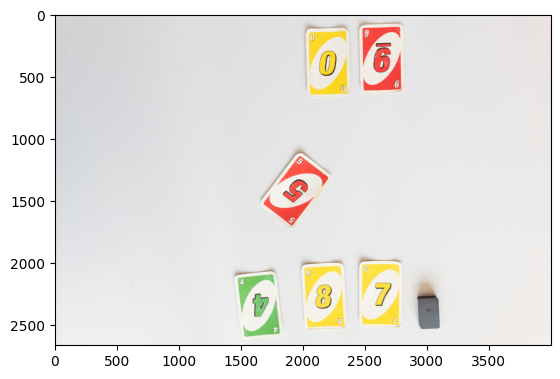

In [159]:
from enum import IntEnum

BLACK = [0, 0, 0]
RED = [255, 0, 0]
GREEN = [0, 255, 0]
BLUE = [0, 0, 255]


class IDX(IntEnum):
    IMAGE_ID = 0
    CENTER_CARD = 1
    ACTIVE_PLAYER = 2
    PLAYER_1_CARDS = 3
    PLAYER_2_CARDS = 4
    PLAYER_3_CARDS = 5
    PLAYER_4_CARDS = 6

def valid_nb(n):
    # as we have 81 images

    n = 80 if n > 80 else n
    print('colorized background') if n > 41 else print('white background')
    return n


class image:
    def __init__(self, image_number): # first image: image_number = 0 

        # Written informations
        self.image_number = image_number
        df = pd.read_csv("../data/train.csv")
        self.row = df.iloc[image_number]

        # Image display 
        folder = Path("../data/train_images")
        files = sorted(folder.glob("*.*"))
        files = [f for f in files if f.suffix.lower() in [".jpg", ".jpeg"]]
        im = Image.open(files[self.image_number])
        self.original = np.array(im)

        # Drawings
        self.temp = self.original.copy()


    def show_info(self, idx):
        if idx > 6:
            return self.row
        else:
            return self.row.iloc[idx] 
    

    def display(self, temporary=False):       
        if temporary:
            plt.imshow(self.temp)
        else:
            plt.imshow(self.original)
        
        
    def get(self, temporary = False):
        if temporary:
            return self.temp.copy()
        else:
            return self.original.copy()



    def draw(self, y_start, y_stop, x_start, x_stop, color):
        self.temp[y_start:y_stop, x_start:x_stop] = color


    def erease_drawings(self):
        self.temp = self.original.copy()


    def segment(self, no_player):
        if no_player == 1:
            seg = np.hstack([
                self.original[2200, 1500:2500].copy(),
                self.original[2000, 1500:2500].copy()])
            return seg
        if no_player == 2:
            seg = np.hstack([
                self.original[800:1800, 3100].copy(),
                self.original[800:1800, 3600].copy()])
            return seg
        if no_player == 3:
            seg = np.hstack([
                self.original[250, 1500:2500].copy(),
                self.original[750, 1500:2500].copy()])
            return seg
        if no_player == 4:
            seg = np.hstack([
                self.original[800:1800, 300].copy(),
                self.original[800:1800, 800].copy()])
            return seg
        else:
            print('no player not valid')

        




################################################################
################ Test for any desired image ####################
################################################################
image1 = image(valid_nb(1))

image1.draw(500, 501, 1500, 2500, BLACK)
print(image1.show_info(12))
#print(image1.show_info(IDX.ACTIVE_PLAYER))

image1.display(temporary=False) # not very fancy to print the whole array but still useful to return it 


### Check active players 
Done only with std <=> works for white background

In [ ]:
TH_EMPTY = 10

def search_present(im): #only for white background
    players = [False, False, False, False]

    for i in range(4):
        if np.std(im.segment(i+1))>TH_EMPTY:
            players[i] = True 
        else:
            players[i] = False
    
    return players

def verify_guess(guess, answer):
    result = True

    if (guess==True) and (answer == "EMPTY"):
        result = False
    if (guess==False) and (answer != "EMPTY"):
        result = False

    return result
    

def TEST_search_present():

    for j in range(41):
        im = image(j)
        players = search_present(im)

        for i in range(4):
            guess = players[i]
            answer = im.show_info(IDX.PLAYER_1_CARDS+i)
            if (not verify_guess(guess, answer)):
                print(f"image no: {j} guess: {guess}, answer: {answer}")



In [173]:
TEST_search_present()


164